# Hotspots: exposure rates and a spatial scan experiment

**Time:** 50 minutes · **Prerequisites:** basic Python; run cells from top to bottom.

Separate count from rate; implement a small maximum-statistic permutation test; explain why it is not a reproduction of SaTScan.

[Run this notebook in JupyterLite](https://jltobias.github.io/JupyterLite-Sea-Level-Rise/lite/lab/index.html?path=notebooks/09_hotspots.ipynb) · [Full-screen dashboard](https://jltobias.github.io/JupyterLite-Sea-Level-Rise/dashboard/) · [Official poster](https://plus.iasociety.org/sites/default/files/2024-09/e-poster_755.pdf)

Each notebook runs independently. Use **Run → Run All Cells**; the first package download can take a minute. Save a downloaded copy to keep your work. The read-only book includes executed examples.

In [1]:
# First run downloads Python packages in JupyterLite; subsequent runs use browser caches.
import sys
if sys.platform == 'emscripten':
    import piplite
    await piplite.install(['numpy', 'pandas', 'matplotlib', 'plotly', 'ipywidgets'])
from pathlib import Path
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display, HTML
from coastlab import (DATA, SCENARIOS, YEARS, COLORS, load_data, select, cards,
                      toy_slr, toy_probability, cumulative_probability,
                      haversine_km, show, dashboard, land_traces)
facilities, exposure = load_data()
published = pd.read_csv(DATA / 'poster_aggregates.csv')
print('Ready: public poster aggregates + clearly labeled fictional facility fixtures.')

Ready: public poster aggregates + clearly labeled fictional facility fixtures.


## A cluster requires a denominator and a null model

The poster used SaTScan to examine concentrations of potentially flooded facilities. A large exposed count may simply reflect many facilities. A statistical scan compares an inside-window exposure rate with an outside rate under a specified model, then accounts for examining many windows.

Here we build a small **fictional Bernoulli scan experiment** over predefined geographic circles. This is not SaTScan, does not recreate its Gini selection, and does not reproduce the poster's cluster ranks, radii or p-values. Real replication needs the original case/control definitions, windows, maximum population fraction, projection, simulation settings and parameter files.

Reference: [Kulldorff, spatial scan statistic and SaTScan technical documentation](https://www.satscan.org/techdoc.html).

In [2]:
rows=select(facilities,exposure,scenario='RCP 8.5',year=2100).reset_index(drop=True)
cases=(rows.annual_probability>=.5).to_numpy().astype(int)
windows=[];names=[]
for city,g in rows.groupby('city'):
    lon,lat=g.longitude.mean(),g.latitude.mean()
    distance=np.array([haversine_km(lon,lat,r.longitude,r.latitude) for r in rows.itertuples()])
    for radius in [8,16,24]:
        mask=distance<=radius
        if 0<mask.sum()<len(rows): windows.append(mask);names.append(f'{city}: {radius} km')
windows=np.array(windows)
def log_likelihood(k,n):
    p=np.clip(k/n,1e-12,1-1e-12)
    return k*np.log(p)+(n-k)*np.log1p(-p)
def scan_statistics(labels):
    n=windows.sum(axis=1); k=windows@labels; N=len(labels);K=labels.sum()
    llr=log_likelihood(k,n)+log_likelihood(K-k,N-n)-log_likelihood(K,N)
    return np.where(k/n>(K-k)/(N-n),np.maximum(0,llr),0)
observed=scan_statistics(cases)
winner=int(observed.argmax())
print('Highest-scoring fictional window:',names[winner], 'LLR:',round(observed[winner],3))

Highest-scoring fictional window: Maputo: 16 km LLR: 1.385


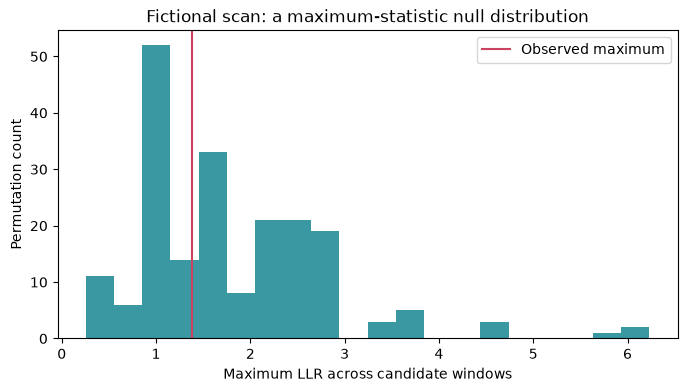

Monte Carlo p-value for strongest tested window: 0.61


In [3]:
# The null holds the total number of cases fixed and permutes their locations.
rng=np.random.default_rng(2024)
null_max=np.array([scan_statistics(rng.permutation(cases)).max() for _ in range(199)])
p_global=(1+np.sum(null_max>=observed.max()))/(1+len(null_max))
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(null_max,bins=20,color='#087e8b',alpha=.8)
ax.axvline(observed.max(),color='#cb4260',label='Observed maximum')
ax.set(xlabel='Maximum LLR across candidate windows',ylabel='Permutation count',title='Fictional scan: a maximum-statistic null distribution');ax.legend();plt.show()
print('Monte Carlo p-value for strongest tested window:',p_global)

## What the test does and does not say

The maximum statistic adjusts this experiment for the set of circles actually searched. It does not fix a poorly chosen null model or unmeasured spatial differences. Exchangeability assumes that shuffling labels is meaningful; unequal topography and shared exposure mechanisms can violate that assumption. The synthetic probabilities and their threshold are inputs, not observed disease cases.

## Lab

Repeat with 999 permutations and thresholds 0.25 and 0.75. Record the top window, global Monte Carlo p-value and case count. Keep the random seed for reproducibility. Explain why a p-value of zero is inappropriate with a finite permutation sample and why the +1 correction matters.

**Worked check:** With 199 simulations the minimum possible corrected p-value is 1/200 = 0.005. Adding candidate windows changes the maximum-statistic null distribution and must be reflected in the test.

**Deliverable:** A short methods paragraph stating the null model, candidate windows, threshold, seed and simulation count, followed by a limitation explaining why this cannot validate the poster's original clusters.